# YOLOv1 Detection Training (Pascal VOC 2012)

End-to-end YOLOv1 fine-tune following the Redmon et al. 2016 recipe, starting from
the backbone checkpoint `yolo-backbone-only.npz` produced by
`YOLO_backbone_insertion.ipynb`.

- Optimizer: SGD + momentum 0.9 + weight decay 5e-4
- LR schedule compressed to 60 epochs (1 warmup + 34 @ 1e-2 + 15 @ 1e-3 + 10 @ 1e-4)
- Paper augmentation (scale/translate +/- 20%, HSV jitter x1.5) on GPU
- Per-epoch checkpoints pushed to Google Drive


In [1]:
!rm -rf /content/yolov1-cupy
!git clone https://github.com/mihnea-popescu/yolov1-cupy.git

import sys
sys.path.append('/content/yolov1-cupy')

from main import TestClass
test = TestClass()
test.test()


Cloning into 'yolov1-cupy'...
remote: Enumerating objects: 188, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 188 (delta 11), reused 25 (delta 9), pack-reused 159 (from 1)
Receiving objects: 100% (188/188), 81.80 MiB | 38.32 MiB/s, done.
Resolving deltas: 100% (94/94), done.
Github classes initialized!


In [2]:
# Pascal VOC 2012 dataset download + extract (Kaggle)
!curl -L -o /content/pascal-voc-2012-dataset.zip https://www.kaggle.com/api/v1/datasets/download/gopalbhattrai/pascal-voc-2012-dataset
print("Extracting Pascal VOC dataset (quiet unzip)...")
!unzip -q /content/pascal-voc-2012-dataset.zip -d /content/yolov1-cupy
!rm /content/pascal-voc-2012-dataset.zip
print("Pascal VOC dataset ready under /content/yolov1-cupy (VOC2012_train_val / VOC2012_test)")


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 3605M  100 3605M    0     0  39.7M      0  0:01:30  0:01:30 --:--:-- 40.8M
Extracting Pascal VOC dataset (quiet unzip)...
Pascal VOC dataset ready under /content/yolov1-cupy (VOC2012_train_val / VOC2012_test)


In [3]:
# Mount Google Drive and copy the backbone-only checkpoint locally.
# Copying to local avoids pinning npz reads through Drive's FUSE layer.
from google.colab import drive
drive.mount('/content/drive')

import os, shutil

DRIVE_CKPT_PATH = "/content/drive/MyDrive/yolov1-cupy/yolo-backbone-only.npz"
LOCAL_CKPT_PATH = "/content/yolov1-cupy/yolo-backbone-only.npz"

assert os.path.isfile(DRIVE_CKPT_PATH), f"Not found in Drive: {DRIVE_CKPT_PATH}"
shutil.copy2(DRIVE_CKPT_PATH, LOCAL_CKPT_PATH)
print("Backbone checkpoint copied to", LOCAL_CKPT_PATH)

DRIVE_CKPT_DIR = "/content/drive/MyDrive/yolov1-cupy/checkpoints"
os.makedirs(DRIVE_CKPT_DIR, exist_ok=True)

LOCAL_CKPT_DIR = "/content/yolov1-cupy/models"
os.makedirs(LOCAL_CKPT_DIR, exist_ok=True)

LOCAL_LOG_PATH = "/content/yolov1-cupy/models/yolo_training_logs.log"
DRIVE_LOG_PATH = "/content/drive/MyDrive/yolov1-cupy/checkpoints/yolo_training_logs.log"


Mounted at /content/drive
Backbone checkpoint copied to /content/yolov1-cupy/yolo-backbone-only.npz


In [4]:
# Build YOLOv1 model, load backbone weights, allocate optimizer buffers,
# and dump a detailed parameter-count summary for both backbone and head.
from yolo import YOLO
from conv2d import Conv2D
from batchnorm2d import BatchNorm2D
from linear import Linear

yolo = YOLO(num_classes=20)
yolo.load_weights(LOCAL_CKPT_PATH)
yolo.init_optimizer()

# Silence the per-layer forward debug prints from yolo.py (kept in the source
# file on purpose, but we don't want 16 lines per batch during training).
import types

def _silent_forward(self, x):
    assert x.ndim == 4, f"Expected NCHW, got shape {x.shape}"
    assert x.shape[1] == 3, f"Expected 3 input channels, got {x.shape[1]}"
    for layer in self.backbone:
        x = layer.forward(x)
    for layer in self.head:
        x = layer.forward(x)
    return x

yolo.forward = types.MethodType(_silent_forward, yolo)


def _count_params(layer):
    n = 0
    if isinstance(layer, Conv2D):
        n += int(layer.weights.size)
        if layer.bias is not None:
            n += int(layer.bias.size)
    elif isinstance(layer, BatchNorm2D) and layer.affine:
        n += int(layer.gamma.size) + int(layer.beta.size)
    elif isinstance(layer, Linear):
        n += int(layer.W.size)
        if layer.use_bias:
            n += int(layer.b.size)
    return n


def _summarize_section(name, layers):
    total = 0
    by_type = {}
    counts = {}
    for layer in layers:
        n = _count_params(layer)
        total += n
        cname = type(layer).__name__
        by_type[cname] = by_type.get(cname, 0) + n
        counts[cname] = counts.get(cname, 0) + 1

    print(f"-- {name}: {total:>12,} params across {len(layers)} layers --")
    for cname in sorted(by_type, key=lambda k: -by_type[k]):
        if by_type[cname] > 0:
            print(f"   {cname:14s} x{counts[cname]:>3d}   {by_type[cname]:>12,} params")
        else:
            print(f"   {cname:14s} x{counts[cname]:>3d}   (no params)")
    return total


print("=" * 64)
print("YOLOv1 model summary")
print("=" * 64)
total_backbone = _summarize_section("Backbone", yolo.backbone)
print()
total_head = _summarize_section("Head",     yolo.head)
grand_total = total_backbone + total_head
print("=" * 64)
print(f"Total trainable parameters: {grand_total:,}  (~{grand_total/1e6:.2f} M)")
print("Optimizer: SGD + momentum 0.9 + weight decay 5e-4 (velocity buffers allocated)")
print("=" * 64)


YOLOv1 model summary
-- Backbone:   22,412,224 params across 64 layers --
   Conv2D         x 20     22,394,048 params
   BatchNorm2D    x 20         18,176 params
   LeakyReLU      x 20   (no params)
   MaxPool2D      x  4   (no params)

-- Head:  249,298,944 params across 17 layers --
   Linear         x  2    211,542,016 params
   Conv2D         x  4     37,748,736 params
   BatchNorm2D    x  4          8,192 params
   LeakyReLU      x  5   (no params)
   Flatten        x  1   (no params)
   Dropout        x  1   (no params)
Total trainable parameters: 271,711,168  (~271.71 M)
Optimizer: SGD + momentum 0.9 + weight decay 5e-4 (velocity buffers allocated)


In [ ]:
# Hyperparameters (paper, with 60-epoch compressed schedule).
BATCH_SIZE   = 64
NUM_EPOCHS   = 60
MOMENTUM     = 0.9
WEIGHT_DECAY = 5e-4
LAMBDA_COORD = 5.0
LAMBDA_NOOBJ = 0.5

# Per-element cap on the (already mean-normalised) gradient wrt logits. The
# YOLOv1 sum-squared loss on (sqrt(w) - sqrt(gw))^2 has an unbounded derivative
# as predicted w -> 0, which on a freshly-initialised head produces O(1e4)
# gradient spikes. The loss.py fix zeroes the branch where w <= clip-eps, and
# this clip handles the remaining "small-but-positive w" regime. With logits
# at std ~3e-2 this cap is an order of magnitude above any "real" gradient.
GRAD_ELEM_CLIP = 10.0

# Global L2-norm cap on parameter gradients across the whole network. The head
# Linear layer multiplies grad-wrt-logits by a 50,176-dim flattened backbone
# activation, so even a well-behaved per-element loss-grad (<=10) can produce
# |dW| in the hundreds. With SGD+momentum 0.9 and a warmup LR ramping to 1e-2,
# unclipped parameter grads that big rewrite the Kaiming-initialised head
# weights (~4.5e-3 per element) many times over in a single step and the run
# diverges after ~25 iterations. 35.0 is a conservative value borrowed from
# the standard "clip_grad_norm_(35)" used in many detection codebases.
MAX_PARAM_GRAD_NORM = 35.0

REPO = "/content/yolov1-cupy"
VOC_DATA_ROOT = "/content/yolov1-cupy"

S, B, C = 7, 2, 20
IMG_SIZE = (448, 448)


In [ ]:
# LR schedule: compressed paper ratio, 60 epochs total.
# Epoch 0: warmup 1e-3 -> 1e-2 linearly over one epoch
# Epochs 1..34:  1e-2  (34 epochs)
# Epochs 35..49: 1e-3  (15 epochs)
# Epochs 50..59: 1e-4  (10 epochs)
def lr_at(epoch, step, steps_per_epoch):
    if epoch == 0:
        return 1e-3 + (1e-2 - 1e-3) * (step / max(steps_per_epoch, 1))
    if epoch < 35:
        return 1e-2
    if epoch < 50:
        return 1e-3
    return 1e-4


In [7]:
# Dataset sizing and batch counts.
from image_batch_loader import voc_dataset_size, voc_num_batches_per_epoch

n_train_imgs = voc_dataset_size(REPO, data_root=VOC_DATA_ROOT, split="train")
n_val_imgs   = voc_dataset_size(REPO, data_root=VOC_DATA_ROOT, split="val")

n_train_batches = voc_num_batches_per_epoch(
    REPO, BATCH_SIZE, data_root=VOC_DATA_ROOT, split="train",
)
n_val_batches = voc_num_batches_per_epoch(
    REPO, BATCH_SIZE, data_root=VOC_DATA_ROOT, split="val",
)

total_train_steps = NUM_EPOCHS * n_train_batches
total_train_imgs  = NUM_EPOCHS * n_train_imgs

print("=" * 64)
print("Pascal VOC 2012 dataset")
print("=" * 64)
print(f"  train images : {n_train_imgs:>6d}    batches/epoch : {n_train_batches:>5d}")
print(f"    val images : {n_val_imgs:>6d}    batches/epoch : {n_val_batches:>5d}")
print(f"  image size   : {IMG_SIZE[0]} x {IMG_SIZE[1]}    batch size : {BATCH_SIZE}")
print(f"  grid S = {S}   B = {B}   C = {C}   (target shape {S}x{S}x{B*5+C})")
print("-" * 64)
print(f"  epochs                : {NUM_EPOCHS}")
print(f"  total training steps  : {total_train_steps:,}")
print(f"  total image passes    : {total_train_imgs:,}")
print("=" * 64)


Pascal VOC 2012 dataset
  train images :   5717    batches/epoch :    90
    val images :   5823    batches/epoch :    91
  image size   : 448 x 448    batch size : 64
  grid S = 7   B = 2   C = 20   (target shape 7x7x30)
----------------------------------------------------------------
  epochs                : 60
  total training steps  : 5,400
  total image passes    : 343,020


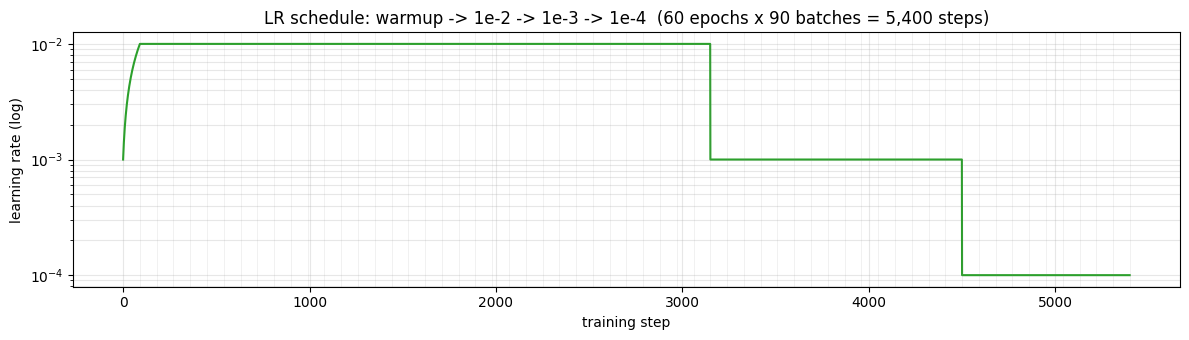

LR range : min=1.0e-04  max=1.0e-02


In [8]:
# Visualize the LR schedule across all planned training steps.
import numpy as np
import matplotlib.pyplot as plt

_lr_preview = np.array([
    lr_at(ep, st, n_train_batches)
    for ep in range(NUM_EPOCHS)
    for st in range(n_train_batches)
], dtype=np.float32)

fig_lr, ax_lr = plt.subplots(figsize=(12, 3.5))
ax_lr.plot(_lr_preview, color="tab:green", linewidth=1.5)
for ep_boundary in range(1, NUM_EPOCHS + 1):
    ax_lr.axvline(ep_boundary * n_train_batches, color="gray", alpha=0.15, linewidth=0.5)
ax_lr.set_yscale("log")
ax_lr.set_xlabel("training step")
ax_lr.set_ylabel("learning rate (log)")
ax_lr.set_title(
    f"LR schedule: warmup -> 1e-2 -> 1e-3 -> 1e-4  "
    f"({NUM_EPOCHS} epochs x {n_train_batches} batches = {len(_lr_preview):,} steps)"
)
ax_lr.grid(alpha=0.3, which="both")
fig_lr.tight_layout()
plt.show()

print(f"LR range : min={_lr_preview.min():.1e}  max={_lr_preview.max():.1e}")

preview batch x shape=(8, 3, 448, 448) dtype=float32
preview batch y shape=(8, 7, 7, 30) dtype=float32
objects encoded in batch: 20


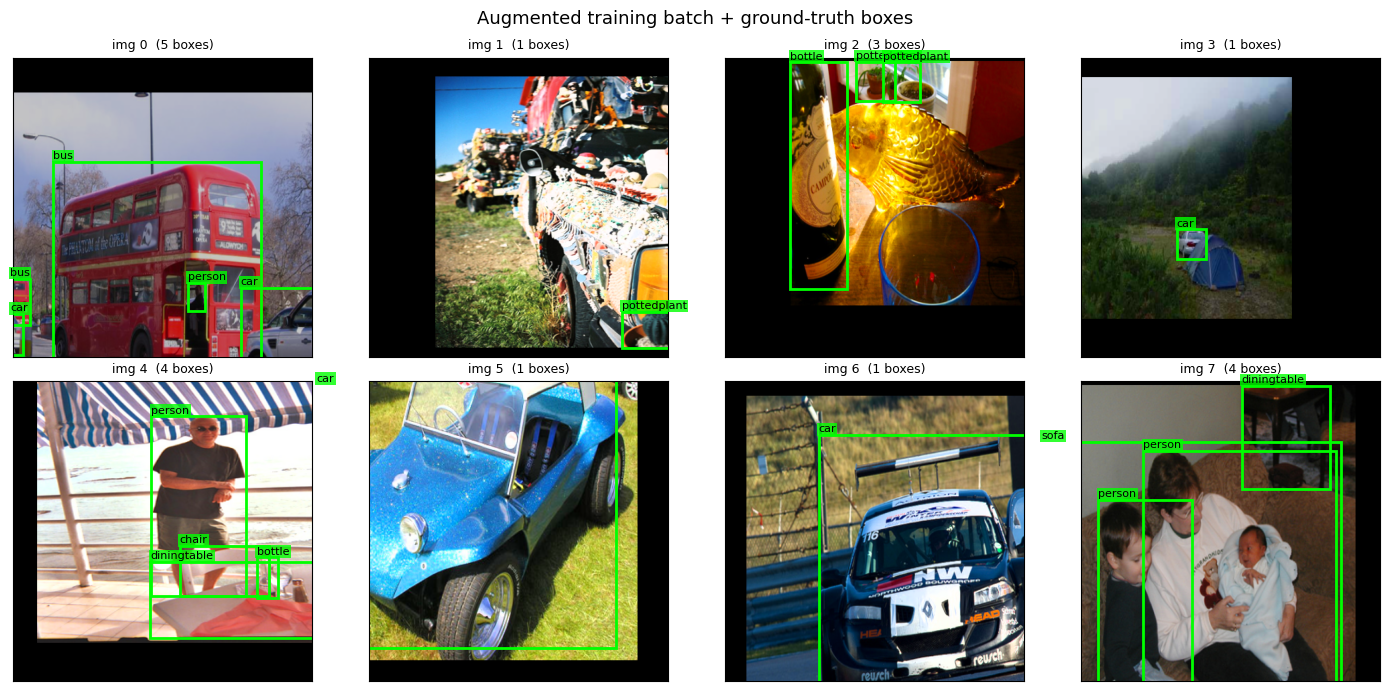

In [9]:
# Preview one augmented training batch with ground-truth boxes overlaid.
# Confirms the data pipeline (decode + augment + encode) is sane before we start.
import cupy as cp
import matplotlib.patches as mpatches
from image_batch_loader import voc_image_target_batch_fast, VOC_CLASS_NAMES

x_preview, y_preview = voc_image_target_batch_fast(
    REPO, batch_size=8,
    seed=0, batch_index=0,
    data_root=VOC_DATA_ROOT, split="train",
    size=IMG_SIZE, s=S, b=B, c=C,
    augment=True,
)
x_preview_np = cp.asnumpy(x_preview)
y_preview_np = cp.asnumpy(y_preview)
print(f"preview batch x shape={x_preview_np.shape} dtype={x_preview_np.dtype}")
print(f"preview batch y shape={y_preview_np.shape} dtype={y_preview_np.dtype}")
print(f"objects encoded in batch: {int((y_preview_np[..., 4] > 0).sum())}")

H_img, W_img = IMG_SIZE[1], IMG_SIZE[0]
fig_prev, axes_prev = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes_prev.flat):
    img = np.transpose(x_preview_np[i], (1, 2, 0))
    ax.imshow(np.clip(img, 0.0, 1.0))
    ax.set_xticks([]); ax.set_yticks([])

    n_boxes = 0
    for gy in range(S):
        for gx in range(S):
            if y_preview_np[i, gy, gx, 4] > 0.0:
                x_in_cell = float(y_preview_np[i, gy, gx, 0])
                y_in_cell = float(y_preview_np[i, gy, gx, 1])
                bw = float(y_preview_np[i, gy, gx, 2])
                bh = float(y_preview_np[i, gy, gx, 3])
                cls_idx = int(np.argmax(y_preview_np[i, gy, gx, B * 5:]))

                cx = (gx + x_in_cell) / S
                cy = (gy + y_in_cell) / S
                px = (cx - bw / 2) * W_img
                py = (cy - bh / 2) * H_img
                pw = bw * W_img
                ph = bh * H_img

                rect = mpatches.Rectangle(
                    (px, py), pw, ph,
                    linewidth=2, edgecolor="lime", facecolor="none",
                )
                ax.add_patch(rect)
                ax.text(
                    px, max(py - 4, 0),
                    VOC_CLASS_NAMES[cls_idx],
                    color="black",
                    fontsize=8,
                    bbox=dict(facecolor="lime", edgecolor="none", pad=1, alpha=0.8),
                )
                n_boxes += 1
    ax.set_title(f"img {i}  ({n_boxes} boxes)", fontsize=9)

fig_prev.suptitle("Augmented training batch + ground-truth boxes", fontsize=13)
fig_prev.tight_layout()
plt.show()

Dashboard ready. Plots will refresh in place at the end of every epoch.


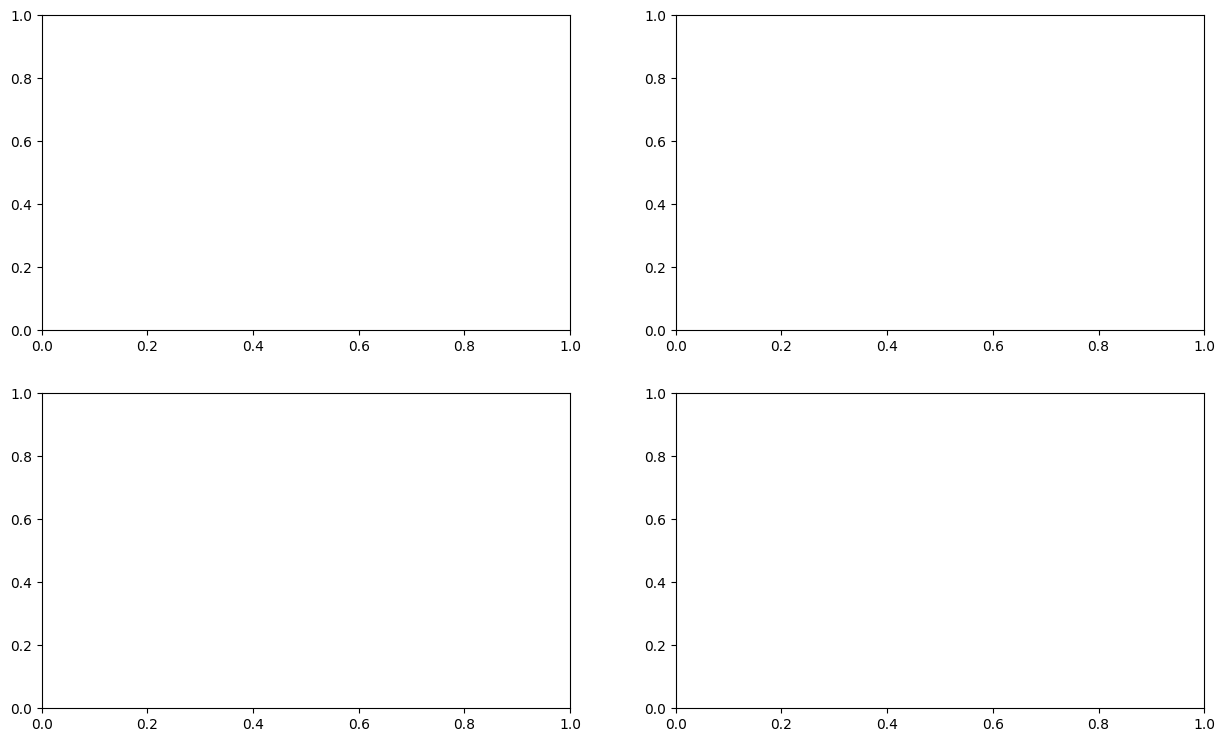

In [10]:
# Live training-metrics tracker with auto-refreshing matplotlib dashboard.
from IPython.display import display

train_loss_per_batch = []
train_loss_ema       = []
lr_history           = []
epoch_boundary_step  = []
epoch_train_losses   = []
epoch_val_losses     = []
epoch_times          = []

_EMA_ALPHA = 0.02

fig_dash, axes_dash = plt.subplots(2, 2, figsize=(15, 9))
_dash_handle = None

PROGRESS_PNG_LOCAL = "/content/yolov1-cupy/models/training_progress.png"
PROGRESS_PNG_DRIVE = "/content/drive/MyDrive/yolov1-cupy/checkpoints/training_progress.png"


def _smoothed(values, k):
    if len(values) < k:
        return values
    import numpy as np
    w = np.ones(k) / k
    return list(np.convolve(values, w, mode="valid"))


def render_dashboard(epoch_idx, total_epochs):
    for row in axes_dash:
        for ax in row:
            ax.clear()

    ax = axes_dash[0][0]
    ax.plot(train_loss_per_batch, color="tab:blue", alpha=0.25, label="per-batch")
    if len(train_loss_ema) == len(train_loss_per_batch):
        ax.plot(train_loss_ema, color="tab:blue", linewidth=2, label=f"EMA (alpha={_EMA_ALPHA})")
    for b in epoch_boundary_step:
        ax.axvline(b, color="gray", linestyle="--", alpha=0.3, linewidth=0.8)
    ax.set_xlabel("batch")
    ax.set_ylabel("loss")
    ax.set_title(f"Train loss per batch (epoch {epoch_idx}/{total_epochs})")
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)

    ax = axes_dash[0][1]
    es = list(range(1, len(epoch_train_losses) + 1))
    if es:
        ax.plot(es, epoch_train_losses, "o-", label="train", color="tab:blue")
        for x, y in zip(es, epoch_train_losses):
            ax.annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=(0, 6), fontsize=7, color="tab:blue")
    if epoch_val_losses:
        es_v = list(range(1, len(epoch_val_losses) + 1))
        ax.plot(es_v, epoch_val_losses, "s-", label="val", color="tab:orange")
        for x, y in zip(es_v, epoch_val_losses):
            ax.annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=(0, -12), fontsize=7, color="tab:orange")
    ax.set_xlabel("epoch")
    ax.set_ylabel("average loss")
    ax.set_title("Epoch average loss")
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes_dash[1][0]
    ax.plot(lr_history, color="tab:green", linewidth=1.2)
    for b in epoch_boundary_step:
        ax.axvline(b, color="gray", linestyle="--", alpha=0.3, linewidth=0.8)
    ax.set_xlabel("batch")
    ax.set_ylabel("learning rate")
    ax.set_title("Learning rate schedule (actual)")
    ax.set_yscale("log")
    ax.grid(alpha=0.3, which="both")

    ax = axes_dash[1][1]
    if epoch_times:
        xs = list(range(1, len(epoch_times) + 1))
        ax.bar(xs, epoch_times, color="tab:purple", alpha=0.8)
        mean_time = sum(epoch_times) / len(epoch_times)
        ax.axhline(mean_time, color="black", linestyle="--", linewidth=1,
                   label=f"mean = {mean_time:.1f}s")
        ax.legend()
    ax.set_xlabel("epoch")
    ax.set_ylabel("seconds")
    ax.set_title("Wall time per epoch")
    ax.grid(alpha=0.3, axis="y")

    fig_dash.suptitle(
        f"YOLOv1 training progress  -  epoch {epoch_idx}/{total_epochs}",
        fontsize=14,
    )
    fig_dash.tight_layout(rect=[0, 0, 1, 0.96])

    try:
        fig_dash.savefig(PROGRESS_PNG_LOCAL, dpi=100)
        shutil.copy2(PROGRESS_PNG_LOCAL, PROGRESS_PNG_DRIVE)
    except Exception as exc:
        print(f"  [warn] failed to save progress figure: {exc}")

    global _dash_handle
    if _dash_handle is None:
        _dash_handle = display(fig_dash, display_id=True)
    else:
        _dash_handle.update(fig_dash)


print("Dashboard ready. Plots will refresh in place at the end of every epoch.")

In [11]:
# =============================================================================
# Pre-flight NaN/Inf diagnostic. Run ONE full step (data load -> forward -> loss
# -> grad -> backward) on a real batch, both with and without augmentation, and
# report exactly where the first NaN/Inf appears. Fails loudly if anything is
# off so we never start a 60-epoch run on a broken pipeline.
# =============================================================================
import cupy as cp
import numpy as np

from image_batch_loader import voc_image_target_batch_fast
from loss import yolo_loss, yolo_loss_grad


def _stats(tag, arr):
    if isinstance(arr, cp.ndarray):
        a = cp.asnumpy(arr)
    else:
        a = np.asarray(arr)
    nan_n = int(np.isnan(a).sum())
    inf_n = int(np.isinf(a).sum())
    flag = "  OK " if (nan_n == 0 and inf_n == 0) else " BAD "
    print(f"  [{flag}] {tag:<36s}  shape={str(a.shape):<22s} "
          f"mean={a.mean():>+9.3e}  std={a.std():>9.3e}  "
          f"min={a.min():>+9.3e}  max={a.max():>+9.3e}  "
          f"NaN={nan_n}  Inf={inf_n}")
    return nan_n, inf_n


def _trace_forward(model, x):
    """Run forward layer-by-layer and flag the first NaN/Inf."""
    print("  ---- forward trace ----")
    h = x
    first_bad = None
    for tag, layer in (
        [("backbone", lyr) for lyr in model.backbone]
        + [("head",     lyr) for lyr in model.head]
    ):
        h = layer.forward(h)
        name = f"{tag}:{type(layer).__name__}"
        a = cp.asnumpy(h) if isinstance(h, cp.ndarray) else np.asarray(h)
        nan_n = int(np.isnan(a).sum())
        inf_n = int(np.isinf(a).sum())
        if nan_n or inf_n:
            if first_bad is None:
                first_bad = (name, a.shape, nan_n, inf_n)
                finite = a[np.isfinite(a)]
                amax = float(np.abs(finite).max()) if finite.size else float('nan')
                print(f"     [FIRST BAD] {name} shape={a.shape}  NaN={nan_n} Inf={inf_n}")
                print(f"                 finite abs-max={amax:.3e}  mean={a.mean():+.3e}  std={a.std():.3e}")
    if first_bad is None:
        a = cp.asnumpy(h)
        print(f"  forward OK: logits shape={a.shape} mean={a.mean():+.3e} std={a.std():.3e}")
    return h, first_bad


def _run_diag(augment):
    header = f" diag: augment={augment} "
    print("-" * 72)
    print(header.center(72, "-"))
    print("-" * 72)

    x, y = voc_image_target_batch_fast(
        REPO, batch_size=BATCH_SIZE,
        seed=0, batch_index=0,
        data_root=VOC_DATA_ROOT, split="train",
        size=IMG_SIZE, s=S, b=B, c=C,
        augment=augment,
    )
    _stats("input x (after augment)" if augment else "input x", x)
    _stats("target y", y)

    yolo.train() if augment else yolo.eval()
    logits, bad = _trace_forward(yolo, x)
    if bad is not None:
        print(f"  --> forward produced NaN/Inf at {bad[0]}. STOP.")
        return False

    _stats("logits", logits)

    loss = yolo_loss(logits, y, S=S, B=B, C=C,
                     lambda_coord=LAMBDA_COORD, lambda_noobj=LAMBDA_NOOBJ)
    print(f"  loss value : {loss:.6f}  (finite={np.isfinite(loss)})")
    if not np.isfinite(loss):
        print("  --> loss is NaN/Inf. STOP.")
        return False

    grad = yolo_loss_grad(logits, y, S=S, B=B, C=C,
                          lambda_coord=LAMBDA_COORD, lambda_noobj=LAMBDA_NOOBJ)
    n1, i1 = _stats("grad wrt logits", grad)
    if n1 or i1:
        print("  --> grad wrt logits has NaN/Inf. STOP.")
        return False

    yolo.zero_grad()
    yolo.backward(grad)

    max_per_layer = []
    for name, lyr in (
        [("backbone", l) for l in yolo.backbone]
        + [("head",     l) for l in yolo.head]
    ):
        if isinstance(lyr, Conv2D):
            arr = cp.asnumpy(lyr.dW)
        elif isinstance(lyr, BatchNorm2D) and lyr.affine:
            arr = cp.asnumpy(lyr.dgamma)
        elif isinstance(lyr, Linear):
            arr = cp.asnumpy(lyr.dW)
        else:
            continue
        n = int(np.isnan(arr).sum())
        i = int(np.isinf(arr).sum())
        max_per_layer.append((f"{name}:{type(lyr).__name__}", float(np.abs(arr).max()), n, i))
    print("  ---- |dW|.max() per trainable layer (top 8) ----")
    for row in sorted(max_per_layer, key=lambda r: -r[1])[:8]:
        print(f"     {row[0]:<30s}  max|dW|={row[1]:>9.3e}   NaN={row[2]}  Inf={row[3]}")
    any_bad = any(r[2] or r[3] for r in max_per_layer)
    if any_bad:
        print("  --> some dW have NaN/Inf. STOP.")
        return False
    print("  diag passed.")
    return True


ok_no_aug = _run_diag(augment=False)
ok_aug    = _run_diag(augment=True)
print("=" * 72)
if ok_no_aug and ok_aug:
    print("  PRE-FLIGHT OK - pipeline is numerically clean. Safe to train.")
else:
    print("  PRE-FLIGHT FAILED - fix the BAD row above before running the training cell.")
print("=" * 72)

------------------------------------------------------------------------
------------------------- diag: augment=False --------------------------
------------------------------------------------------------------------
  [  OK ] input x                               shape=(64, 3, 448, 448)      mean=+4.173e-01  std=2.838e-01  min=+0.000e+00  max=+1.000e+00  NaN=0  Inf=0
  [  OK ] target y                              shape=(64, 7, 7, 30)         mean=+6.961e-03  std=7.519e-02  min=+0.000e+00  max=+1.000e+00  NaN=0  Inf=0
  ---- forward trace ----
  forward OK: logits shape=(64, 1470) mean=+2.258e-04 std=3.443e-02
  [  OK ] logits                                shape=(64, 1470)             mean=+2.258e-04  std=3.443e-02  min=-1.625e-01  max=+1.514e-01  NaN=0  Inf=0
  loss value : 1410.841309  (finite=True)
  [  OK ] grad wrt logits                       shape=(64, 1470)             mean=-8.293e-02  std=2.974e+00  min=-7.708e+02  max=+9.383e-01  NaN=0  Inf=0
  ---- |dW|.max() per trainab

################################################################
# Starting YOLOv1 training: 60 epochs x 90 batches
# Batch size 64, images per epoch = 5717
# Logs  -> /content/yolov1-cupy/models/yolo_training_logs.log
# Drive -> /content/drive/MyDrive/yolov1-cupy/checkpoints
################################################################


[train 01/60]:   0%|          | 0/90 [00:00<?, ?it/s]

[ val  01/60]:   0%|          | 0/91 [00:00<?, ?it/s]


+--------------------------------------------------------------+
|  epoch   1/60   -  finished in 7m48s                     |
+--------------------------------------------------------------+
|  train loss (avg) :    31.7276                              |
|  val   loss (avg) :    28.8771   best :    28.8771  <-- NEW BEST|
|  LR               : start 1.0e-03  end 9.9e-03                |
|  imgs/sec (train) :       12.2                              |
|  total elapsed    : 7m48s          ETA : 7h40m48s                |
+--------------------------------------------------------------+
epoch 001/60 train_loss=31.7276 val_loss=28.8771 best=28.8771 lr_start=1.0e-03 lr_end=9.9e-03 time=468.6s elapsed=7m48s eta=7h40m48s


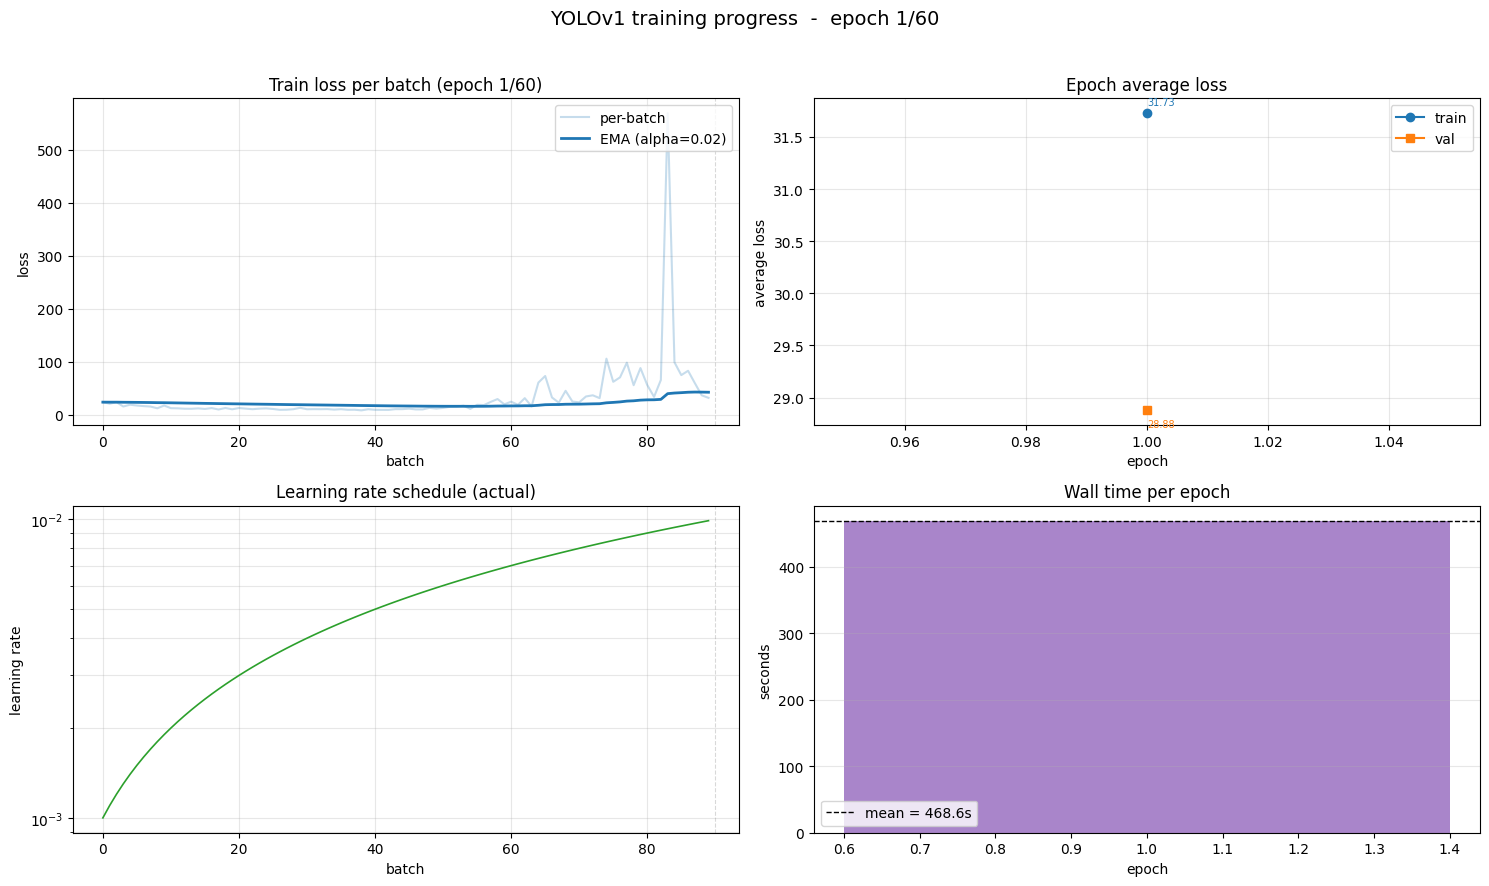

  saved checkpoint: /content/yolov1-cupy/models/yolo-epoch1.npz
           -> drive: /content/drive/MyDrive/yolov1-cupy/checkpoints/yolo-epoch1.npz
  best checkpoint updated: /content/drive/MyDrive/yolov1-cupy/checkpoints/yolo-best.npz


[train 02/60]:   0%|          | 0/90 [00:00<?, ?it/s]

In [ ]:
# Training + validation loop.
#
# The BatchPrefetcher overlaps CPU data prep with GPU forward/backward/update.
# Every batch we update:
#   - tqdm postfix (current loss, EMA loss, LR, images/sec)
#   - the global per-batch / LR histories used by render_dashboard()
#
# At the end of every epoch we:
#   - run validation (its own tqdm bar)
#   - print a pretty boxed summary
#   - re-render the dashboard (train loss / val loss / LR / epoch time)
#   - save a checkpoint locally and copy to Drive
import time
import cupy as cp
from tqdm.auto import tqdm

from loss import yolo_loss, yolo_loss_grad
from image_batch_loader import BatchPrefetcher


_GRAD_ATTRS = ("dW", "db", "dgamma", "dbeta")


def _iter_param_grads(model):
    """Yield every non-None gradient tensor in the model (Conv2D/Linear dW/db,
    BatchNorm2D dgamma/dbeta). Used for global grad-norm clipping."""
    for layer in list(model.backbone) + list(model.head):
        for attr in _GRAD_ATTRS:
            g = getattr(layer, attr, None)
            if g is not None:
                yield g


def clip_parameter_grad_norm(model, max_norm):
    """Global L2-norm clip across every parameter gradient in the model.
    Returns the (pre-clip) total gradient norm as a Python float so it can be
    logged. Single device->host sync per step."""
    total_sq = cp.zeros((), dtype=cp.float32)
    for g in _iter_param_grads(model):
        total_sq += (g * g).sum(dtype=cp.float32)
    total_norm = float(cp.sqrt(total_sq))
    if total_norm > max_norm and total_norm > 0.0:
        scale = max_norm / (total_norm + 1e-8)
        for g in _iter_param_grads(model):
            g *= scale
    return total_norm


def _log_line(line):
    print(line)
    with open(LOCAL_LOG_PATH, "a") as handle:
        handle.write(line + "\n")
    try:
        shutil.copy2(LOCAL_LOG_PATH, DRIVE_LOG_PATH)
    except Exception:
        pass


def _fmt_seconds(seconds):
    seconds = int(seconds)
    h, r = divmod(seconds, 3600)
    m, s = divmod(r, 60)
    if h:
        return f"{h:d}h{m:02d}m{s:02d}s"
    if m:
        return f"{m:d}m{s:02d}s"
    return f"{s:d}s"


print("#" * 64)
print(f"# Starting YOLOv1 training: {NUM_EPOCHS} epochs x {n_train_batches} batches")
print(f"# Batch size {BATCH_SIZE}, images per epoch = {n_train_imgs}")
print(f"# Logs  -> {LOCAL_LOG_PATH}")
print(f"# Drive -> {DRIVE_CKPT_DIR}")
print("#" * 64)

best_val = float("inf")
training_started = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_started = time.time()

    # -------------------------------
    # Training phase
    # -------------------------------
    yolo.train()
    train_loss_sum = 0.0
    train_loss_count = 0
    running_ema = None
    imgs_seen = 0

    train_pref = BatchPrefetcher(
        REPO, BATCH_SIZE,
        seed=epoch, data_root=VOC_DATA_ROOT, split="train",
        n_batches=n_train_batches,
        size=IMG_SIZE, s=S, b=B, c=C,
        augment=True,
    )
    pbar = tqdm(
        train_pref,
        total=n_train_batches,
        desc=f"[train {epoch+1:02d}/{NUM_EPOCHS:02d}]",
        leave=True,
        dynamic_ncols=True,
    )
    try:
        for step, (x, y) in enumerate(pbar):
            lr = lr_at(epoch, step, n_train_batches)
            yolo.zero_grad()
            logits = yolo.forward(x)
            loss = yolo_loss(
                logits, y,
                S=S, B=B, C=C,
                lambda_coord=LAMBDA_COORD, lambda_noobj=LAMBDA_NOOBJ,
            )
            grad = yolo_loss_grad(
                logits, y,
                S=S, B=B, C=C,
                lambda_coord=LAMBDA_COORD, lambda_noobj=LAMBDA_NOOBJ,
            )
            # yolo_loss / yolo_loss_grad return a SUM over the batch. Convert to
            # a per-image MEAN by dividing both the scalar and the gradient by
            # the actual batch size (handles the final partial batch correctly).
            batch_n = float(x.shape[0])
            grad = grad / batch_n
            # Per-element safety clip on the loss gradient. With the loss.py
            # wh-gradient fix in place, grad-wrt-logits should already sit at
            # O(1) per element; this cap is a belt-and-suspenders guard against
            # any remaining sqrt-branch spikes from near-zero w/h predictions.
            cp.clip(grad, -GRAD_ELEM_CLIP, GRAD_ELEM_CLIP, out=grad)

            yolo.backward(grad)
            # Global L2-norm clip on parameter gradients. Returns the pre-clip
            # norm so we can log it alongside the loss (spikes here are the
            # canary for instability).
            pre_clip_gnorm = clip_parameter_grad_norm(yolo, MAX_PARAM_GRAD_NORM)
            yolo.sgd_momentum_step(lr, MOMENTUM, WEIGHT_DECAY)

            # Display / track the per-image mean loss to match the mean-loss
            # gradient we just backpropagated. This is what the loss curves will
            # show and what we compare across epochs.
            loss_f = float(loss) / batch_n
            if not np.isfinite(loss_f):
                print(f"\n!!! non-finite loss at epoch {epoch+1} step {step}: loss={loss_f}")
                print("    run the pre-flight diagnostic cell above to locate the source.")
                raise RuntimeError(f"loss became {loss_f}; aborting training.")
            train_loss_sum += loss_f
            train_loss_count += 1
            imgs_seen += int(x.shape[0])

            running_ema = loss_f if running_ema is None else (
                (1 - _EMA_ALPHA) * running_ema + _EMA_ALPHA * loss_f
            )

            train_loss_per_batch.append(loss_f)
            train_loss_ema.append(running_ema)
            lr_history.append(lr)

            elapsed = max(time.time() - epoch_started, 1e-6)
            pbar.set_postfix({
                "loss":    f"{loss_f:.3f}",
                "ema":     f"{running_ema:.3f}",
                "avg":     f"{train_loss_sum/train_loss_count:.3f}",
                "lr":      f"{lr:.1e}",
                "gnorm":   f"{pre_clip_gnorm:.2f}",
                "img/s":   f"{imgs_seen/elapsed:5.1f}",
            })
    finally:
        pbar.close()
        train_pref.close()

    train_avg = train_loss_sum / max(train_loss_count, 1)
    epoch_boundary_step.append(len(train_loss_per_batch))
    epoch_train_losses.append(train_avg)

    # -------------------------------
    # Validation phase
    # -------------------------------
    yolo.eval()
    val_loss_sum = 0.0
    val_loss_count = 0
    val_pref = BatchPrefetcher(
        REPO, BATCH_SIZE,
        seed=0, data_root=VOC_DATA_ROOT, split="val",
        n_batches=n_val_batches,
        size=IMG_SIZE, s=S, b=B, c=C,
        augment=False,
    )
    vbar = tqdm(
        val_pref,
        total=n_val_batches,
        desc=f"[ val  {epoch+1:02d}/{NUM_EPOCHS:02d}]",
        leave=True,
        dynamic_ncols=True,
    )
    try:
        for x, y in vbar:
            logits = yolo.forward(x)
            vloss = float(yolo_loss(
                logits, y,
                S=S, B=B, C=C,
                lambda_coord=LAMBDA_COORD, lambda_noobj=LAMBDA_NOOBJ,
            )) / float(x.shape[0])
            val_loss_sum += vloss
            val_loss_count += 1
            vbar.set_postfix({
                "loss": f"{vloss:.3f}",
                "avg":  f"{val_loss_sum/val_loss_count:.3f}",
            })
    finally:
        vbar.close()
        val_pref.close()

    val_avg = val_loss_sum / max(val_loss_count, 1)
    epoch_val_losses.append(val_avg)
    epoch_elapsed = time.time() - epoch_started
    epoch_times.append(epoch_elapsed)

    lr_start = lr_at(epoch, 0, n_train_batches)
    lr_end   = lr_at(epoch, n_train_batches - 1, n_train_batches)

    total_elapsed = time.time() - training_started
    remaining = (epoch_elapsed * (NUM_EPOCHS - epoch - 1))

    is_best = val_avg < best_val
    if is_best:
        best_val = val_avg
    best_marker = "  <-- NEW BEST" if is_best else ""

    # -------------------------------
    # Pretty epoch summary
    # -------------------------------
    print()
    print("+" + "-" * 62 + "+")
    print(f"|  epoch {epoch+1:>3d}/{NUM_EPOCHS:<3d}  -  finished in {_fmt_seconds(epoch_elapsed):<12s}" + " " * 14 + "|")
    print("+" + "-" * 62 + "+")
    print(f"|  train loss (avg) : {train_avg:>10.4f}"
          + " " * 30 + "|")
    print(f"|  val   loss (avg) : {val_avg:>10.4f}   best : {best_val:>10.4f}{best_marker:<13s}|")
    print(f"|  LR               : start {lr_start:.1e}  end {lr_end:.1e}"
          + " " * 16 + "|")
    print(f"|  imgs/sec (train) : {imgs_seen / max(epoch_elapsed, 1e-6):>10.1f}"
          + " " * 30 + "|")
    print(f"|  total elapsed    : {_fmt_seconds(total_elapsed):<12s}   ETA : {_fmt_seconds(remaining):<14s}"
          + " " * 10 + "|")
    print("+" + "-" * 62 + "+")

    _log_line(
        f"epoch {epoch+1:03d}/{NUM_EPOCHS} "
        f"train_loss={train_avg:.4f} val_loss={val_avg:.4f} best={best_val:.4f} "
        f"lr_start={lr_start:.1e} lr_end={lr_end:.1e} "
        f"time={epoch_elapsed:.1f}s elapsed={_fmt_seconds(total_elapsed)} "
        f"eta={_fmt_seconds(remaining)}"
    )

    # -------------------------------
    # Dashboard refresh
    # -------------------------------
    render_dashboard(epoch + 1, NUM_EPOCHS)

    # -------------------------------
    # Checkpoint
    # -------------------------------
    local_ckpt = os.path.join(LOCAL_CKPT_DIR, f"yolo-epoch{epoch+1}.npz")
    drive_ckpt = os.path.join(DRIVE_CKPT_DIR, f"yolo-epoch{epoch+1}.npz")
    yolo.save_weights(local_ckpt)
    shutil.copy2(local_ckpt, drive_ckpt)
    print(f"  saved checkpoint: {local_ckpt}")
    print(f"           -> drive: {drive_ckpt}")
    if is_best:
        best_local = os.path.join(LOCAL_CKPT_DIR, "yolo-best.npz")
        best_drive = os.path.join(DRIVE_CKPT_DIR, "yolo-best.npz")
        shutil.copy2(local_ckpt, best_local)
        shutil.copy2(best_local, best_drive)
        print(f"  best checkpoint updated: {best_drive}")

print()
print("#" * 64)
print(f"# Training complete in {_fmt_seconds(time.time() - training_started)}")
print(f"# Best val loss: {best_val:.4f}")
print("#" * 64)


In [ ]:
# =============================================================================
# Post-training sanity check. Run this cell after training finishes to verify:
#   1. all expected checkpoints exist locally + on Drive (with byte sizes)
#   2. the training log is well-formed
#   3. the best checkpoint round-trips through YOLO.save_weights/load_weights
#   4. the reloaded model runs a forward pass in eval mode on a val batch
#   5. training curves make sense (loss decreased, NaN-free)
#   6. a small qualitative visualization of predicted confidence heatmaps
# =============================================================================
import numpy as np
import cupy as cp

print("=" * 72)
print("POST-TRAINING SANITY CHECK")
print("=" * 72)

# ---------- 1. checkpoint inventory ----------
print("\n[1/6] Checkpoint inventory")
missing_local = []
missing_drive = []
sizes = []
for ep in range(1, NUM_EPOCHS + 1):
    local_path = os.path.join(LOCAL_CKPT_DIR, f"yolo-epoch{ep}.npz")
    drive_path = os.path.join(DRIVE_CKPT_DIR, f"yolo-epoch{ep}.npz")
    if os.path.isfile(local_path):
        sizes.append(os.path.getsize(local_path))
    else:
        missing_local.append(ep)
    if not os.path.isfile(drive_path):
        missing_drive.append(ep)

best_local = os.path.join(LOCAL_CKPT_DIR, "yolo-best.npz")
best_drive = os.path.join(DRIVE_CKPT_DIR, "yolo-best.npz")
has_best_local = os.path.isfile(best_local)
has_best_drive = os.path.isfile(best_drive)

n_local = NUM_EPOCHS - len(missing_local)
n_drive = NUM_EPOCHS - len(missing_drive)
mean_mb = (sum(sizes) / len(sizes)) / (1024 * 1024) if sizes else 0.0
print(f"  local  : {n_local:>3d}/{NUM_EPOCHS} found   (avg {mean_mb:.1f} MB per file)")
print(f"  drive  : {n_drive:>3d}/{NUM_EPOCHS} found")
print(f"  best   : local={'OK' if has_best_local else 'MISSING'}   "
      f"drive={'OK' if has_best_drive else 'MISSING'}")
if missing_local:
    print(f"  [warn] missing locally : {missing_local}")
if missing_drive:
    print(f"  [warn] missing on drive: {missing_drive}")

# ---------- 2. log file check ----------
print("\n[2/6] Training log")
if os.path.isfile(LOCAL_LOG_PATH):
    with open(LOCAL_LOG_PATH) as handle:
        log_lines = handle.readlines()
    print(f"  {LOCAL_LOG_PATH}  ({len(log_lines)} lines)")
    for line in log_lines[-5:]:
        print(f"    {line.rstrip()}")
else:
    print(f"  [warn] no log file at {LOCAL_LOG_PATH}")

# ---------- 3. checkpoint round-trip ----------
print("\n[3/6] Checkpoint round-trip test (load + save + reload)")
reload_path = best_local if has_best_local else os.path.join(
    LOCAL_CKPT_DIR, f"yolo-epoch{NUM_EPOCHS}.npz"
)
assert os.path.isfile(reload_path), f"No checkpoint to reload at {reload_path}"
print(f"  source : {reload_path}")

_test_yolo = YOLO(num_classes=20)
_test_yolo.load_weights(reload_path)
_test_yolo.eval()
_test_yolo.forward = types.MethodType(_silent_forward, _test_yolo)

tmp_ckpt = "/content/yolov1-cupy/models/_roundtrip.npz"
_test_yolo.save_weights(tmp_ckpt)
_test_yolo_2 = YOLO(num_classes=20)
_test_yolo_2.load_weights(tmp_ckpt)
_test_yolo_2.forward = types.MethodType(_silent_forward, _test_yolo_2)

param_count_ok = True
nan_count = 0
inf_count = 0
for a, b in zip(
    list(_test_yolo.backbone) + list(_test_yolo.head),
    list(_test_yolo_2.backbone) + list(_test_yolo_2.head),
):
    if isinstance(a, Conv2D):
        nan_count += int(cp.isnan(a.weights).sum().get())
        inf_count += int(cp.isinf(a.weights).sum().get())
        if not cp.allclose(a.weights, b.weights):
            param_count_ok = False
    elif isinstance(a, BatchNorm2D) and a.affine:
        nan_count += int(cp.isnan(a.gamma).sum().get())
        inf_count += int(cp.isinf(a.gamma).sum().get())
        if not cp.allclose(a.gamma, b.gamma) or not cp.allclose(a.beta, b.beta):
            param_count_ok = False
    elif isinstance(a, Linear):
        nan_count += int(cp.isnan(a.W).sum().get())
        inf_count += int(cp.isinf(a.W).sum().get())
        if not cp.allclose(a.W, b.W):
            param_count_ok = False

print(f"  round-trip bitwise match : {'OK' if param_count_ok else 'FAIL'}")
print(f"  NaN params               : {nan_count}")
print(f"  Inf params               : {inf_count}")

# ---------- 4. forward pass on a real val batch ----------
print("\n[4/6] Forward pass on a validation batch (eval mode)")
from image_batch_loader import voc_image_target_batch_fast

x_test, y_test = voc_image_target_batch_fast(
    REPO, batch_size=8,
    seed=0, batch_index=0,
    data_root=VOC_DATA_ROOT, split="val",
    size=IMG_SIZE, s=S, b=B, c=C,
    augment=False,
)
t0 = time.time()
logits_test = _test_yolo_2.forward(x_test)
cp.cuda.Stream.null.synchronize()
fwd_ms = (time.time() - t0) * 1000.0

logits_np = cp.asnumpy(logits_test)
pred_mean = float(logits_np.mean())
pred_std  = float(logits_np.std())
pred_min  = float(logits_np.min())
pred_max  = float(logits_np.max())
has_nan   = bool(np.isnan(logits_np).any())
has_inf   = bool(np.isinf(logits_np).any())

val_loss_test = float(yolo_loss(
    logits_test, y_test,
    S=S, B=B, C=C,
    lambda_coord=LAMBDA_COORD, lambda_noobj=LAMBDA_NOOBJ,
))

print(f"  x shape        : {tuple(x_test.shape)}")
print(f"  logits shape   : {tuple(logits_test.shape)}")
print(f"  forward time   : {fwd_ms:.1f} ms   ({fwd_ms/8:.2f} ms/img)")
print(f"  logits stats   : mean={pred_mean:.4f} std={pred_std:.4f} "
      f"min={pred_min:.4f} max={pred_max:.4f}")
print(f"  NaN in logits  : {has_nan}")
print(f"  Inf in logits  : {has_inf}")
print(f"  val loss here  : {val_loss_test:.4f}  (epoch avg was {epoch_val_losses[-1]:.4f})")

# ---------- 5. training curve sanity ----------
print("\n[5/6] Training curve sanity")
if epoch_train_losses:
    first_tr = epoch_train_losses[0]
    last_tr  = epoch_train_losses[-1]
    first_vl = epoch_val_losses[0] if epoch_val_losses else float("nan")
    last_vl  = epoch_val_losses[-1] if epoch_val_losses else float("nan")
    tr_delta = first_tr - last_tr
    vl_delta = first_vl - last_vl
    any_nan_tr = any(np.isnan(v) for v in epoch_train_losses)
    any_nan_vl = any(np.isnan(v) for v in epoch_val_losses)
    print(f"  epochs completed   : {len(epoch_train_losses)}/{NUM_EPOCHS}")
    print(f"  train loss  first  : {first_tr:>8.4f}")
    print(f"  train loss  last   : {last_tr:>8.4f}   (delta = {tr_delta:+.4f})")
    print(f"    val loss  first  : {first_vl:>8.4f}")
    print(f"    val loss  last   : {last_vl:>8.4f}   (delta = {vl_delta:+.4f})")
    print(f"    val loss  best   : {best_val:>8.4f}")
    print(f"  NaN in train curve : {any_nan_tr}")
    print(f"  NaN in val   curve : {any_nan_vl}")
    if tr_delta > 0 and not any_nan_tr:
        print("  train loss decreased over training  [good]")
    elif any_nan_tr:
        print("  [warn] NaN in train loss curve")
    else:
        print("  [warn] train loss did not decrease")
else:
    print("  [warn] epoch_train_losses is empty - was training run?")

# ---------- 6. final visualization: predicted confidence heatmaps ----------
print("\n[6/6] Predicted-confidence heatmaps on val batch 0")
# For each of the B predictors, grab channel 4 + (b*5) -> confidence map (S,S)
conf_maps = np.zeros((x_test.shape[0], B, S, S), dtype=np.float32)
for bidx in range(B):
    conf_maps[:, bidx] = logits_np.reshape(x_test.shape[0], S, S, B * 5 + C)[..., bidx * 5 + 4]

fig_final, axes_final = plt.subplots(2, 4, figsize=(15, 7))
for i, ax in enumerate(axes_final[0]):
    img = np.transpose(cp.asnumpy(x_test[i]), (1, 2, 0))
    ax.imshow(np.clip(img, 0.0, 1.0))
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"val img {i}", fontsize=9)

for i, ax in enumerate(axes_final[1]):
    im = ax.imshow(conf_maps[i, 0], cmap="hot", interpolation="nearest",
                   vmin=float(conf_maps.min()), vmax=float(conf_maps.max()))
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"conf (pred 0)\nmin={conf_maps[i,0].min():.2f} "
                 f"max={conf_maps[i,0].max():.2f}", fontsize=8)
fig_final.suptitle("Val images + YOLO predictor-0 confidence maps (reloaded best ckpt)",
                   fontsize=12)
fig_final.tight_layout()
plt.show()

# ---------- summary verdict ----------
print("\n" + "=" * 72)
ok = (
    n_local == NUM_EPOCHS
    and n_drive == NUM_EPOCHS
    and has_best_local
    and has_best_drive
    and param_count_ok
    and not has_nan
    and not has_inf
    and epoch_train_losses
    and not any(np.isnan(v) for v in epoch_train_losses)
    and not any(np.isnan(v) for v in epoch_val_losses)
)
if ok:
    print("ALL CHECKS PASSED - training ran smoothly end to end.")
else:
    print("SOME CHECKS FAILED - review the warnings above.")
print("=" * 72)

In [ ]:
# =============================================================================
# Save final run artifacts to /content AND Google Drive:
#   - final sanity-check figure (val images + predictor-0 confidence maps)
#   - refreshed training dashboard PNG
#   - metrics JSON with the full train/val/LR/time history + hyperparameters
#   - run_info.txt human-readable summary
# =============================================================================
import json

FINAL_DIR_LOCAL = "/content/yolov1-cupy/models/final"
FINAL_DIR_DRIVE = "/content/drive/MyDrive/yolov1-cupy/checkpoints/final"
os.makedirs(FINAL_DIR_LOCAL, exist_ok=True)
os.makedirs(FINAL_DIR_DRIVE, exist_ok=True)

# Sanity-check figure
sanity_png_local = os.path.join(FINAL_DIR_LOCAL, "sanity_check.png")
sanity_png_drive = os.path.join(FINAL_DIR_DRIVE, "sanity_check.png")
fig_final.savefig(sanity_png_local, dpi=120, bbox_inches="tight")
shutil.copy2(sanity_png_local, sanity_png_drive)

# Refresh + save the dashboard one more time (no-op if already drawn)
render_dashboard(len(epoch_train_losses), NUM_EPOCHS)
dashboard_png_local = os.path.join(FINAL_DIR_LOCAL, "training_progress.png")
dashboard_png_drive = os.path.join(FINAL_DIR_DRIVE, "training_progress.png")
fig_dash.savefig(dashboard_png_local, dpi=120, bbox_inches="tight")
shutil.copy2(dashboard_png_local, dashboard_png_drive)

# Metrics JSON
metrics = {
    "hyperparameters": {
        "batch_size":     BATCH_SIZE,
        "num_epochs":     NUM_EPOCHS,
        "momentum":       MOMENTUM,
        "weight_decay":   WEIGHT_DECAY,
        "lambda_coord":   LAMBDA_COORD,
        "lambda_noobj":   LAMBDA_NOOBJ,
        "image_size":     list(IMG_SIZE),
        "S": S, "B": B, "C": C,
    },
    "dataset": {
        "train_images":   n_train_imgs,
        "val_images":     n_val_imgs,
        "train_batches_per_epoch": n_train_batches,
        "val_batches_per_epoch":   n_val_batches,
    },
    "results": {
        "epochs_completed":       len(epoch_train_losses),
        "train_loss_per_epoch":   [float(v) for v in epoch_train_losses],
        "val_loss_per_epoch":     [float(v) for v in epoch_val_losses],
        "epoch_time_sec":         [float(v) for v in epoch_times],
        "best_val_loss":          float(best_val),
        "total_batches_seen":     len(train_loss_per_batch),
    },
    "train_loss_per_batch":       [float(v) for v in train_loss_per_batch],
    "train_loss_ema_per_batch":   [float(v) for v in train_loss_ema],
    "lr_per_batch":               [float(v) for v in lr_history],
    "epoch_boundary_step":        [int(v) for v in epoch_boundary_step],
    "sanity_check": {
        "logits_mean":   pred_mean,
        "logits_std":    pred_std,
        "logits_min":    pred_min,
        "logits_max":    pred_max,
        "has_nan":       bool(has_nan),
        "has_inf":       bool(has_inf),
        "forward_ms":    fwd_ms,
        "val_loss_here": val_loss_test,
        "roundtrip_ok":  bool(param_count_ok),
        "weight_nan":    int(nan_count),
        "weight_inf":    int(inf_count),
        "all_checks_passed": bool(ok),
    },
}
metrics_local = os.path.join(FINAL_DIR_LOCAL, "metrics.json")
metrics_drive = os.path.join(FINAL_DIR_DRIVE, "metrics.json")
with open(metrics_local, "w") as handle:
    json.dump(metrics, handle, indent=2)
shutil.copy2(metrics_local, metrics_drive)

# Human-readable summary
info_lines = [
    "YOLOv1 training run summary",
    "=" * 50,
    f"epochs completed   : {len(epoch_train_losses)}/{NUM_EPOCHS}",
    f"batch size         : {BATCH_SIZE}",
    f"train images       : {n_train_imgs}",
    f"val   images       : {n_val_imgs}",
    f"best val loss      : {best_val:.4f}",
    f"final train loss   : {epoch_train_losses[-1]:.4f}" if epoch_train_losses else "final train loss   : n/a",
    f"final val   loss   : {epoch_val_losses[-1]:.4f}" if epoch_val_losses else "final val   loss   : n/a",
    f"total wall time    : {_fmt_seconds(sum(epoch_times))}" if epoch_times else "total wall time    : n/a",
    f"mean epoch time    : {(sum(epoch_times)/len(epoch_times)):.1f}s" if epoch_times else "mean epoch time    : n/a",
    f"sanity checks pass : {ok}",
    "",
    f"final checkpoint   : {reload_path}",
    f"best  checkpoint   : {best_local}",
    f"dashboard (local)  : {dashboard_png_local}",
    f"dashboard (drive)  : {dashboard_png_drive}",
    f"sanity fig (local) : {sanity_png_local}",
    f"sanity fig (drive) : {sanity_png_drive}",
    f"metrics (local)    : {metrics_local}",
    f"metrics (drive)    : {metrics_drive}",
]
info_local = os.path.join(FINAL_DIR_LOCAL, "run_info.txt")
info_drive = os.path.join(FINAL_DIR_DRIVE, "run_info.txt")
with open(info_local, "w") as handle:
    handle.write("\n".join(info_lines) + "\n")
shutil.copy2(info_local, info_drive)

print("=" * 72)
print("Final artifacts saved:")
print("-" * 72)
print(f"  local : {FINAL_DIR_LOCAL}/")
print(f"  drive : {FINAL_DIR_DRIVE}/")
for _p in (sanity_png_local, dashboard_png_local, metrics_local, info_local):
    size_kb = os.path.getsize(_p) / 1024.0
    print(f"    {os.path.basename(_p):<24s}  {size_kb:>8.1f} KB")
print("=" * 72)
print("\n".join(info_lines))